# Q8 — Temporal Patterns: When Are WBGT and PM2.5 Highest?

**Research Question**: What time(s) of day and day(s) of week are associated with the highest wet bulb globe temperatures and PM2.5 overall and for each open space site?

**Chinatown HEROS** | Jul 19 – Aug 23, 2023 | 12 sites | 10-min intervals

---

## Dashboard & Layout Recommendations *(for Design Team)*

> **Visual Hierarchy**:
> 1. **KPI Banner**: Peak hour for PM2.5, Peak hour for WBGT, Peak day-of-week, most affected site
> 2. **Hour × Day Heatmaps** (40%): Dual heatmaps for PM2.5 and WBGT showing the full weekly cycle
> 3. **Diurnal Overlay** (30%): All-site diurnal curves for both variables
> 4. **Site-Specific Small Multiples** (30%): Per-site heatmaps showing when each park is worst
>
> **Interactive Features**: Variable toggle (PM2.5/WBGT), site picker, weekday/weekend filter
>
> **Educational Framing**: *"Chinatown's air is worst at midnight and cleanest at noon — but heat peaks at 3 PM. Know when to go outside."*

## Setup & Data Loading

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import kruskal, mannwhitneyu, f_oneway
from pathlib import Path
import warnings; warnings.filterwarnings('ignore')

FIG_DIR = Path('../../figures/phase3_refined'); FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet('../../data/clean/data_HEROS_clean.parquet')
df['hour'] = df['datetime'].dt.hour
df['dow'] = df['datetime'].dt.day_of_week          # 0=Mon … 6=Sun
df['dow_name'] = df['datetime'].dt.day_name()
df['is_weekend'] = df['dow'].isin([5, 6])

PM = 'pa_mean_pm2_5_atm_b_corr_2'
WBGT = 'kes_mean_wbgt_f'

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# Quick data check
n_pm = df[PM].notna().sum(); n_wb = df[WBGT].notna().sum()
print(f'Dataset: {df.shape[0]:,} rows × {df.shape[1]} cols, {df["site_id"].nunique()} sites')
print(f'PM2.5 valid: {n_pm:,} ({n_pm/len(df)*100:.0f}%)  |  WBGT valid: {n_wb:,} ({n_wb/len(df)*100:.0f}%)')

Dataset: 48,123 rows × 49 cols, 12 sites
PM2.5 valid: 47,009 (98%)  |  WBGT valid: 46,404 (96%)


## KPI Overview — Peak Times

In [2]:
# ── KPI: identify peak hours and days ────────────────────────────
hourly_pm = df.groupby('hour')[PM].mean()
hourly_wb = df.groupby('hour')[WBGT].mean()
dow_pm    = df.groupby('dow_name')[PM].mean().reindex(DOW_ORDER)
dow_wb    = df.groupby('dow_name')[WBGT].mean().reindex(DOW_ORDER)

peak_hr_pm  = int(hourly_pm.idxmax())
trough_hr_pm = int(hourly_pm.idxmin())
peak_hr_wb  = int(hourly_wb.idxmax())
trough_hr_wb = int(hourly_wb.idxmin())
peak_dow_pm = dow_pm.idxmax()
peak_dow_wb = dow_wb.idxmax()

# Weekday vs weekend
wkday_pm = df[~df['is_weekend']][PM].mean()
wkend_pm = df[df['is_weekend']][PM].mean()
wkday_wb = df[~df['is_weekend']][WBGT].mean()
wkend_wb = df[df['is_weekend']][WBGT].mean()

# Diurnal amplitude
pm_amp = hourly_pm.max() - hourly_pm.min()
wb_amp = hourly_wb.max() - hourly_wb.min()

# Kruskal-Wallis tests
groups_hr_pm = [g[PM].dropna().values for _, g in df.groupby('hour')]
groups_hr_wb = [g[WBGT].dropna().values for _, g in df.groupby('hour')]
kw_hr_pm = kruskal(*groups_hr_pm)
kw_hr_wb = kruskal(*groups_hr_wb)

groups_dow_pm = [g[PM].dropna().values for _, g in df.groupby('dow')]
groups_dow_wb = [g[WBGT].dropna().values for _, g in df.groupby('dow')]
kw_dow_pm = kruskal(*groups_dow_pm)
kw_dow_wb = kruskal(*groups_dow_wb)

print('╔═══════════════════════════════════════════════════════════════════╗')
print('║            Q8 — TEMPORAL PATTERN KEY PERFORMANCE INDICATORS       ║')
print('╠═══════════════════════════════════════════════════════════════════╣')
print(f'║ PM2.5 Peak Hour         │ {peak_hr_pm:02d}:00 ({hourly_pm.max():.1f} µg/m³)                    ║')
print(f'║ PM2.5 Trough Hour       │ {trough_hr_pm:02d}:00 ({hourly_pm.min():.1f} µg/m³)                    ║')
print(f'║ PM2.5 Diurnal Amplitude  │ {pm_amp:.1f} µg/m³                                  ║')
print(f'║ PM2.5 Peak Day-of-Week   │ {peak_dow_pm} ({dow_pm.max():.1f} µg/m³)               ║')
print(f'║ WBGT Peak Hour           │ {peak_hr_wb:02d}:00 ({hourly_wb.max():.1f} °F)                      ║')
print(f'║ WBGT Trough Hour         │ {trough_hr_wb:02d}:00 ({hourly_wb.min():.1f} °F)                      ║')
print(f'║ WBGT Diurnal Amplitude   │ {wb_amp:.1f} °F                                     ║')
print(f'║ WBGT Peak Day-of-Week    │ {peak_dow_wb} ({dow_wb.max():.1f} °F)                 ║')
print(f'║ Weekday vs Weekend PM2.5 │ {wkday_pm:.1f} vs {wkend_pm:.1f} µg/m³                       ║')
print(f'║ Weekday vs Weekend WBGT  │ {wkday_wb:.1f} vs {wkend_wb:.1f} °F                         ║')
print('╠═══════════════════════════════════════════════════════════════════╣')
print(f'║ Hour effect on PM2.5     │ H={kw_hr_pm.statistic:.0f}, p={kw_hr_pm.pvalue:.2e}              ║')
print(f'║ Hour effect on WBGT      │ H={kw_hr_wb.statistic:.0f}, p={kw_hr_wb.pvalue:.2e}              ║')
print(f'║ DOW effect on PM2.5      │ H={kw_dow_pm.statistic:.0f}, p={kw_dow_pm.pvalue:.2e}               ║')
print(f'║ DOW effect on WBGT       │ H={kw_dow_wb.statistic:.0f}, p={kw_dow_wb.pvalue:.2e}               ║')
print('╚═══════════════════════════════════════════════════════════════════╝')

╔═══════════════════════════════════════════════════════════════════╗
║            Q8 — TEMPORAL PATTERN KEY PERFORMANCE INDICATORS       ║
╠═══════════════════════════════════════════════════════════════════╣
║ PM2.5 Peak Hour         │ 12:00 (10.6 µg/m³)                    ║
║ PM2.5 Trough Hour       │ 01:00 (8.5 µg/m³)                    ║
║ PM2.5 Diurnal Amplitude  │ 2.1 µg/m³                                  ║
║ PM2.5 Peak Day-of-Week   │ Monday (10.9 µg/m³)               ║
║ WBGT Peak Hour           │ 17:00 (67.2 °F)                      ║
║ WBGT Trough Hour         │ 06:00 (64.2 °F)                      ║
║ WBGT Diurnal Amplitude   │ 3.1 °F                                     ║
║ WBGT Peak Day-of-Week    │ Friday (68.1 °F)                 ║
║ Weekday vs Weekend PM2.5 │ 9.3 vs 10.0 µg/m³                       ║
║ Weekday vs Weekend WBGT  │ 66.0 vs 65.6 °F                         ║
╠═══════════════════════════════════════════════════════════════════╣
║ Hour effect on PM2.5     │ H

## Foundational EDA — Diurnal & Weekly Cycles

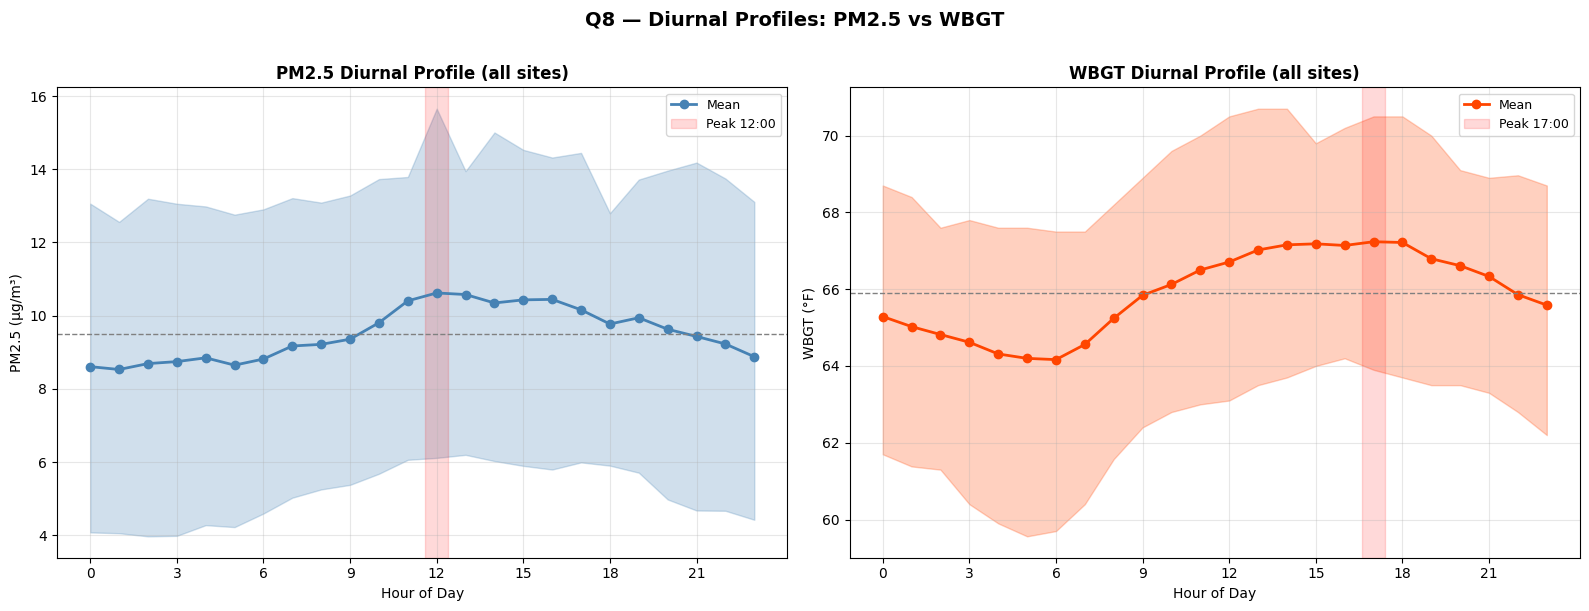

Saved: q8_diurnal_profiles.png


In [3]:
# ── Overall diurnal profiles ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PM2.5 diurnal
ax = axes[0]
h_mean = df.groupby('hour')[PM].mean()
h_q25  = df.groupby('hour')[PM].quantile(0.25)
h_q75  = df.groupby('hour')[PM].quantile(0.75)
ax.fill_between(h_mean.index, h_q25, h_q75, alpha=0.25, color='steelblue')
ax.plot(h_mean.index, h_mean, 'o-', color='steelblue', lw=2, label='Mean')
ax.axhline(h_mean.mean(), ls='--', color='gray', lw=1)
ax.axvspan(peak_hr_pm-0.4, peak_hr_pm+0.4, alpha=0.15, color='red', label=f'Peak {peak_hr_pm}:00')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_title('PM2.5 Diurnal Profile (all sites)', fontsize=12, fontweight='bold')
ax.set_xticks(range(0,24,3)); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# WBGT diurnal
ax = axes[1]
w_mean = df.groupby('hour')[WBGT].mean()
w_q25  = df.groupby('hour')[WBGT].quantile(0.25)
w_q75  = df.groupby('hour')[WBGT].quantile(0.75)
ax.fill_between(w_mean.index, w_q25, w_q75, alpha=0.25, color='orangered')
ax.plot(w_mean.index, w_mean, 'o-', color='orangered', lw=2, label='Mean')
ax.axhline(w_mean.mean(), ls='--', color='gray', lw=1)
ax.axvspan(peak_hr_wb-0.4, peak_hr_wb+0.4, alpha=0.15, color='red', label=f'Peak {peak_hr_wb}:00')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('WBGT (°F)')
ax.set_title('WBGT Diurnal Profile (all sites)', fontsize=12, fontweight='bold')
ax.set_xticks(range(0,24,3)); ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle('Q8 — Diurnal Profiles: PM2.5 vs WBGT', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_diurnal_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_diurnal_profiles.png')

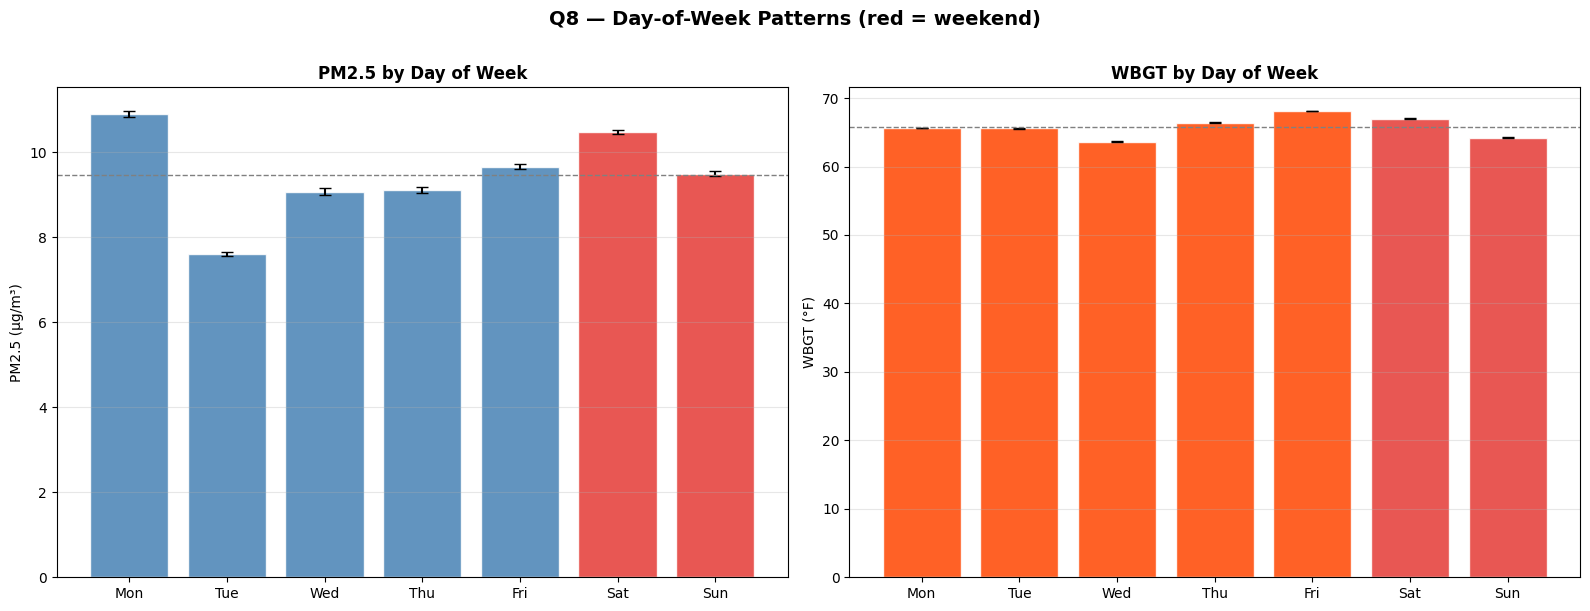

Saved: q8_dow_profiles.png


In [4]:
# ── Day-of-week profiles ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (var, label, cmap) in enumerate([
    (PM, 'PM2.5 (µg/m³)', 'steelblue'),
    (WBGT, 'WBGT (°F)', 'orangered')]):
    ax = axes[i]
    dow_mean = df.groupby('dow_name')[var].mean().reindex(DOW_ORDER)
    dow_std  = df.groupby('dow_name')[var].std().reindex(DOW_ORDER)
    x = range(7)
    colors = ['#E53935' if d in ['Saturday','Sunday'] else cmap for d in DOW_ORDER]
    ax.bar(x, dow_mean, yerr=dow_std/np.sqrt(df.groupby('dow_name')[var].count().reindex(DOW_ORDER)),
           color=colors, edgecolor='white', capsize=4, alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([d[:3] for d in DOW_ORDER], fontsize=10)
    ax.set_ylabel(label); ax.set_title(f'{label.split(" (")[0]} by Day of Week', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    ax.axhline(dow_mean.mean(), ls='--', color='gray', lw=1)

fig.suptitle('Q8 — Day-of-Week Patterns (red = weekend)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_dow_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_dow_profiles.png')

## Core Analysis — Hour × Day-of-Week Heatmaps

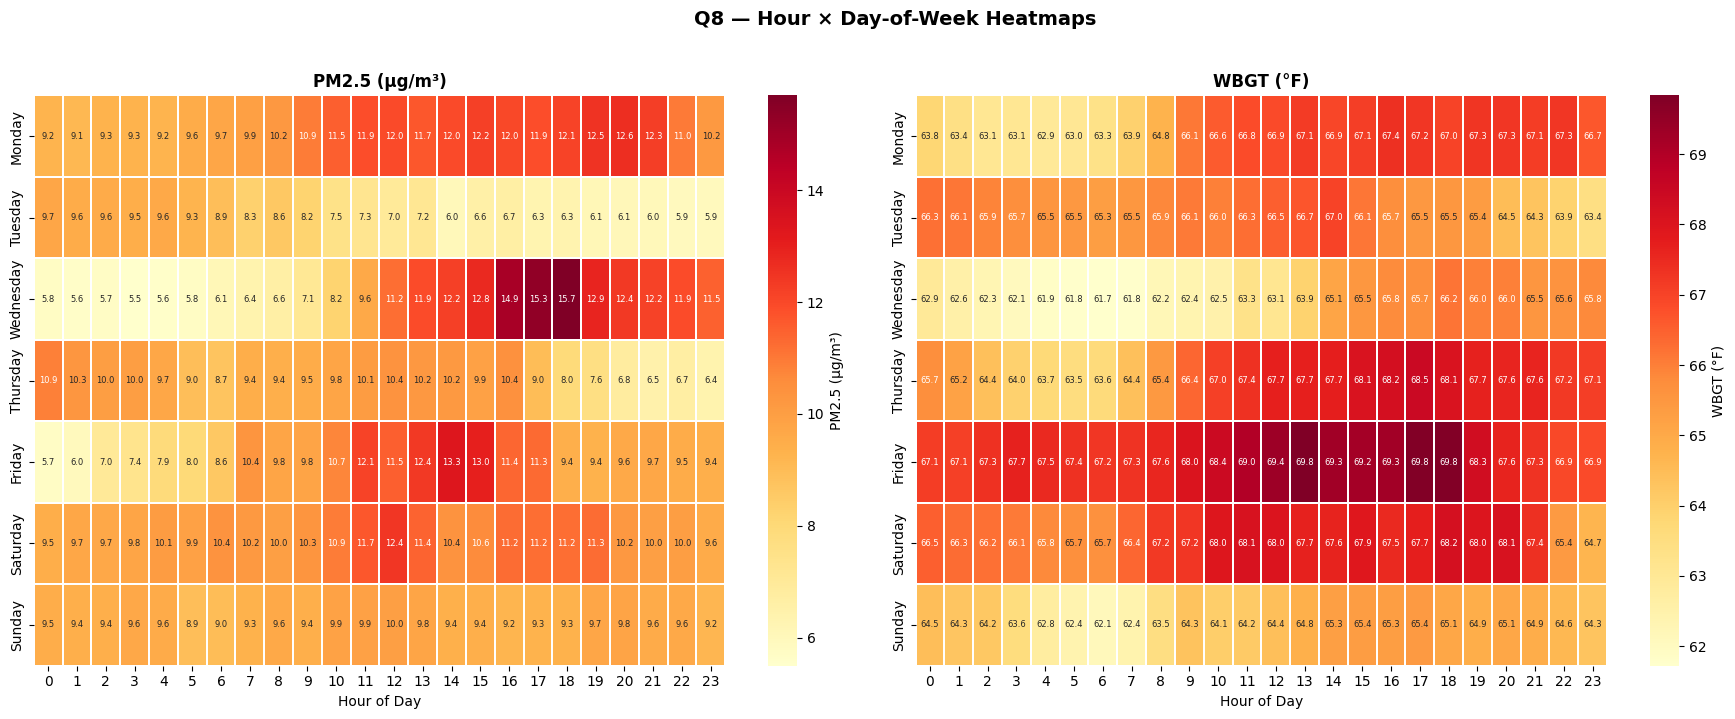

Saved: q8_hour_dow_heatmap.png


In [5]:
# ── Hour × DOW heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (var, title, cmap) in enumerate([
    (PM, 'PM2.5 (µg/m³)', 'YlOrRd'),
    (WBGT, 'WBGT (°F)', 'YlOrRd')]):
    ax = axes[i]
    pivot = df.pivot_table(values=var, index='dow_name', columns='hour', aggfunc='mean')
    pivot = pivot.reindex(DOW_ORDER)
    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt='.1f', linewidths=0.3,
                cbar_kws={'label': title}, annot_kws={'fontsize': 6})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hour of Day'); ax.set_ylabel('')

fig.suptitle('Q8 — Hour × Day-of-Week Heatmaps', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_hour_dow_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_hour_dow_heatmap.png')

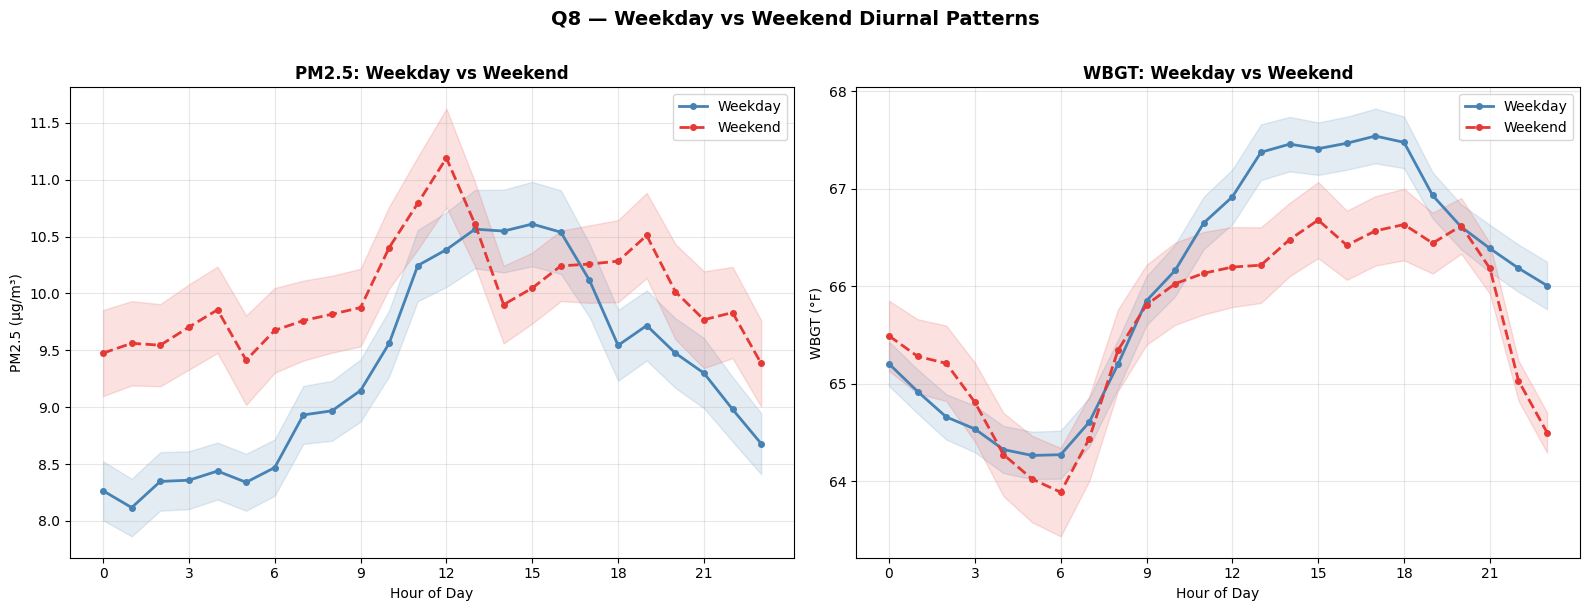

Saved: q8_weekday_weekend.png


In [6]:
# ── Weekday vs Weekend diurnal comparison ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (var, label, unit) in enumerate([
    (PM, 'PM2.5', 'µg/m³'), (WBGT, 'WBGT', '°F')]):
    ax = axes[i]
    for wknd, lbl, clr, ls in [(False, 'Weekday', 'steelblue', '-'), (True, 'Weekend', '#E53935', '--')]:
        sub = df[df['is_weekend']==wknd].groupby('hour')[var].agg(['mean','sem'])
        ax.plot(sub.index, sub['mean'], f'{ls}o', color=clr, lw=2, ms=4, label=lbl)
        ax.fill_between(sub.index, sub['mean']-1.96*sub['sem'], sub['mean']+1.96*sub['sem'],
                       alpha=0.15, color=clr)
    ax.set_xlabel('Hour of Day'); ax.set_ylabel(f'{label} ({unit})')
    ax.set_title(f'{label}: Weekday vs Weekend', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0,24,3)); ax.legend(); ax.grid(alpha=0.3)

fig.suptitle('Q8 — Weekday vs Weekend Diurnal Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_weekday_weekend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_weekday_weekend.png')

## Deep-Dive — Site-Specific Temporal Patterns

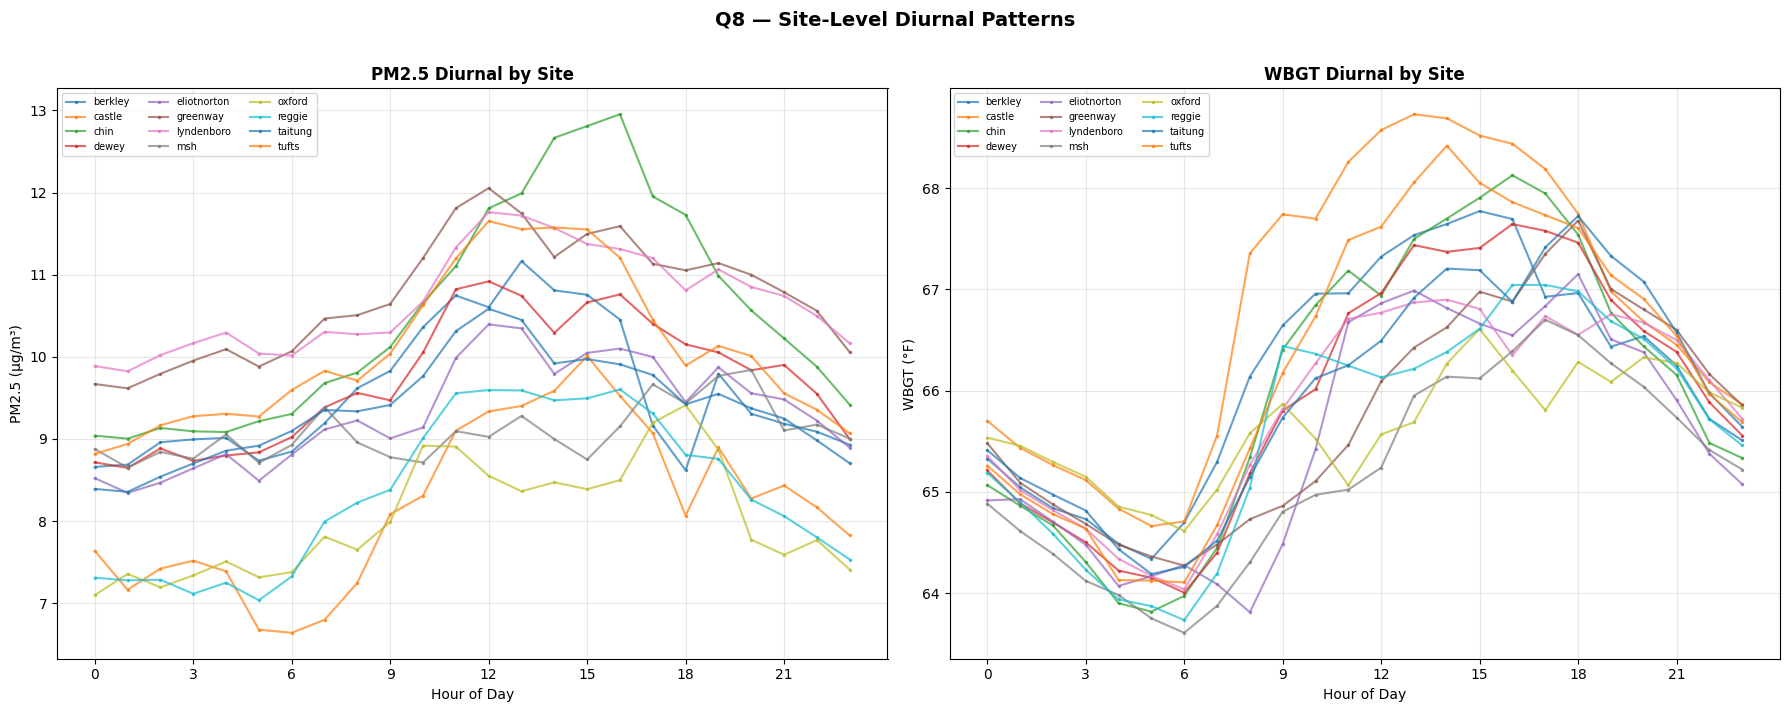

Saved: q8_site_diurnal.png


In [7]:
# ── Site-level diurnal overlay ────────────────────────────────────
sites = sorted(df['site_id'].unique())
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for i, (var, label) in enumerate([(PM, 'PM2.5 (µg/m³)'), (WBGT, 'WBGT (°F)')]):
    ax = axes[i]
    for s in sites:
        h = df[df['site_id']==s].groupby('hour')[var].mean()
        ax.plot(h.index, h.values, marker='.', ms=3, alpha=0.7, label=s)
    ax.set_xlabel('Hour of Day'); ax.set_ylabel(label)
    ax.set_title(f'{label.split(" (")[0]} Diurnal by Site', fontsize=12, fontweight='bold')
    ax.set_xticks(range(0,24,3)); ax.legend(fontsize=7, ncol=3); ax.grid(alpha=0.3)

fig.suptitle('Q8 — Site-Level Diurnal Patterns', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_site_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_site_diurnal.png')

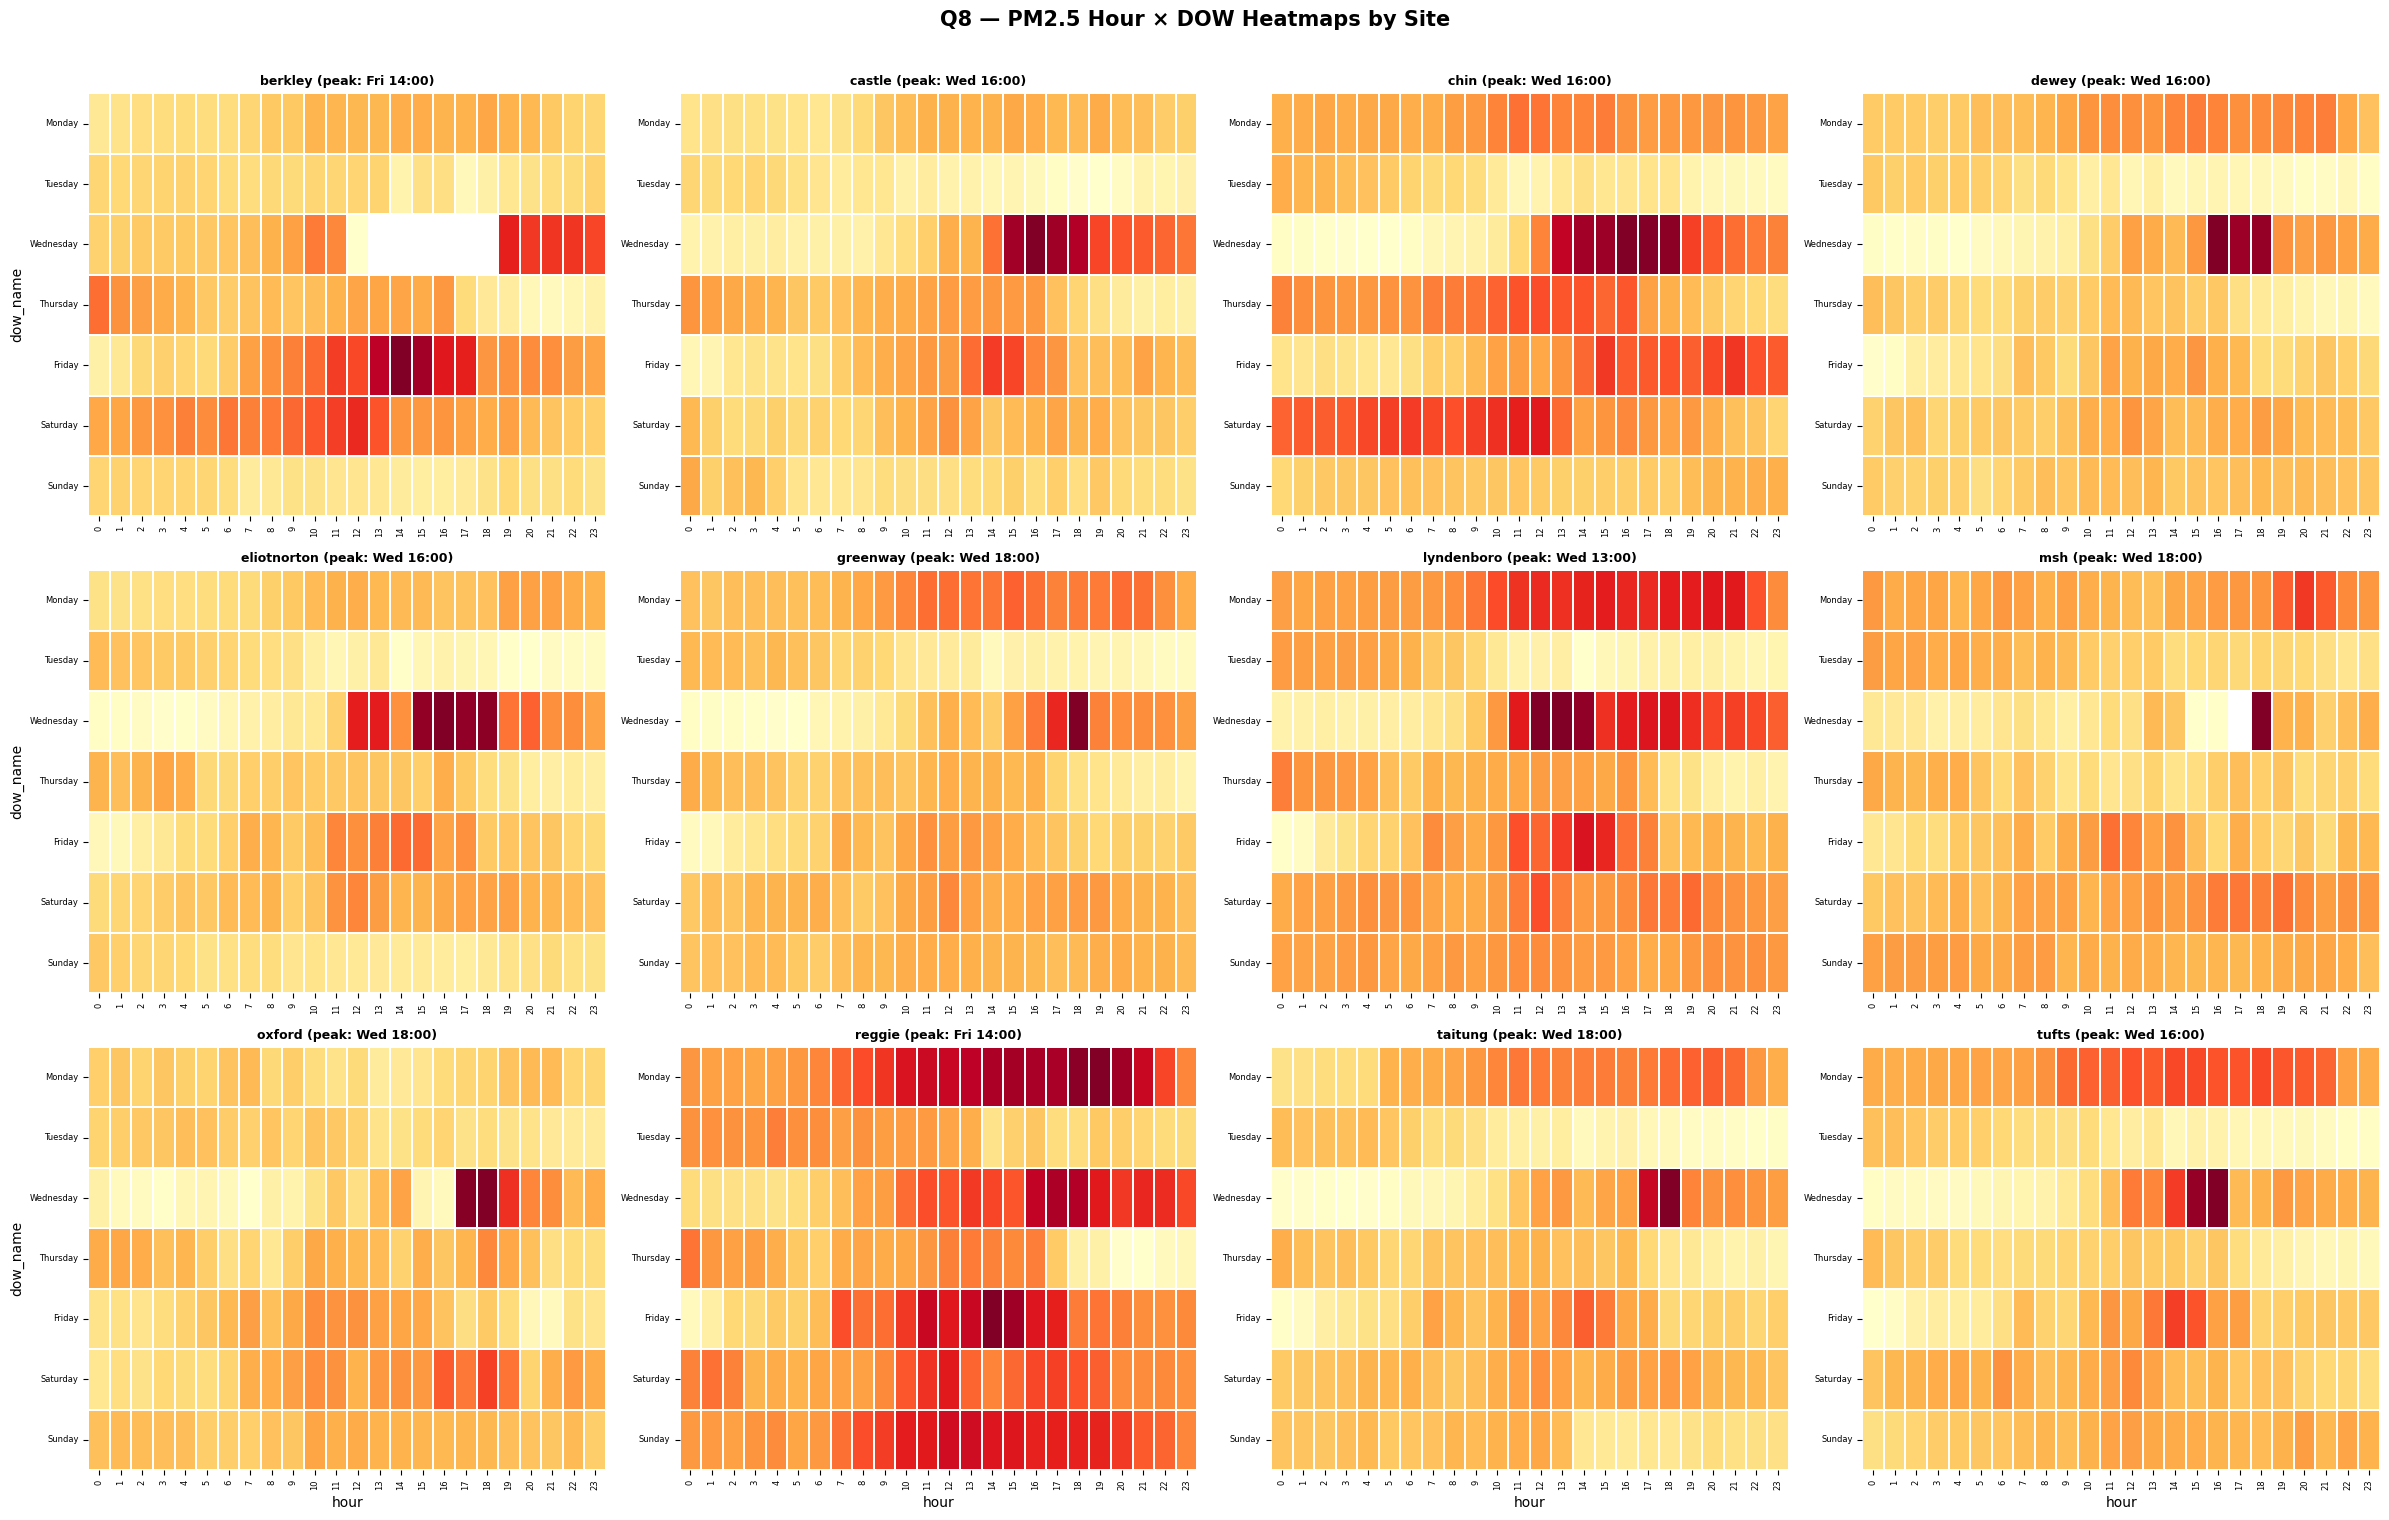

Saved: q8_site_pm25_heatmaps.png


In [8]:
# ── Per-site Hour × DOW heatmaps (small multiples) ──────────────
n_sites = len(sites)
fig, axes = plt.subplots(3, 4, figsize=(24, 15))
axes = axes.flat

for idx, s in enumerate(sites):
    ax = axes[idx]
    pivot = df[df['site_id']==s].pivot_table(values=PM, index='dow_name', columns='hour', aggfunc='mean')
    pivot = pivot.reindex(DOW_ORDER)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar=False, annot=False, linewidths=0.1)
    site_peak_hr = pivot.values.flatten()
    peak_idx = np.unravel_index(np.nanargmax(pivot.values), pivot.shape)
    peak_dow = DOW_ORDER[peak_idx[0]][:3]
    peak_h = pivot.columns[peak_idx[1]]
    ax.set_title(f'{s} (peak: {peak_dow} {peak_h}:00)', fontsize=9, fontweight='bold')
    if idx % 4 != 0: ax.set_ylabel('')
    if idx < 8: ax.set_xlabel('')
    ax.tick_params(labelsize=6)

fig.suptitle('Q8 — PM2.5 Hour × DOW Heatmaps by Site', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_site_pm25_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_site_pm25_heatmaps.png')

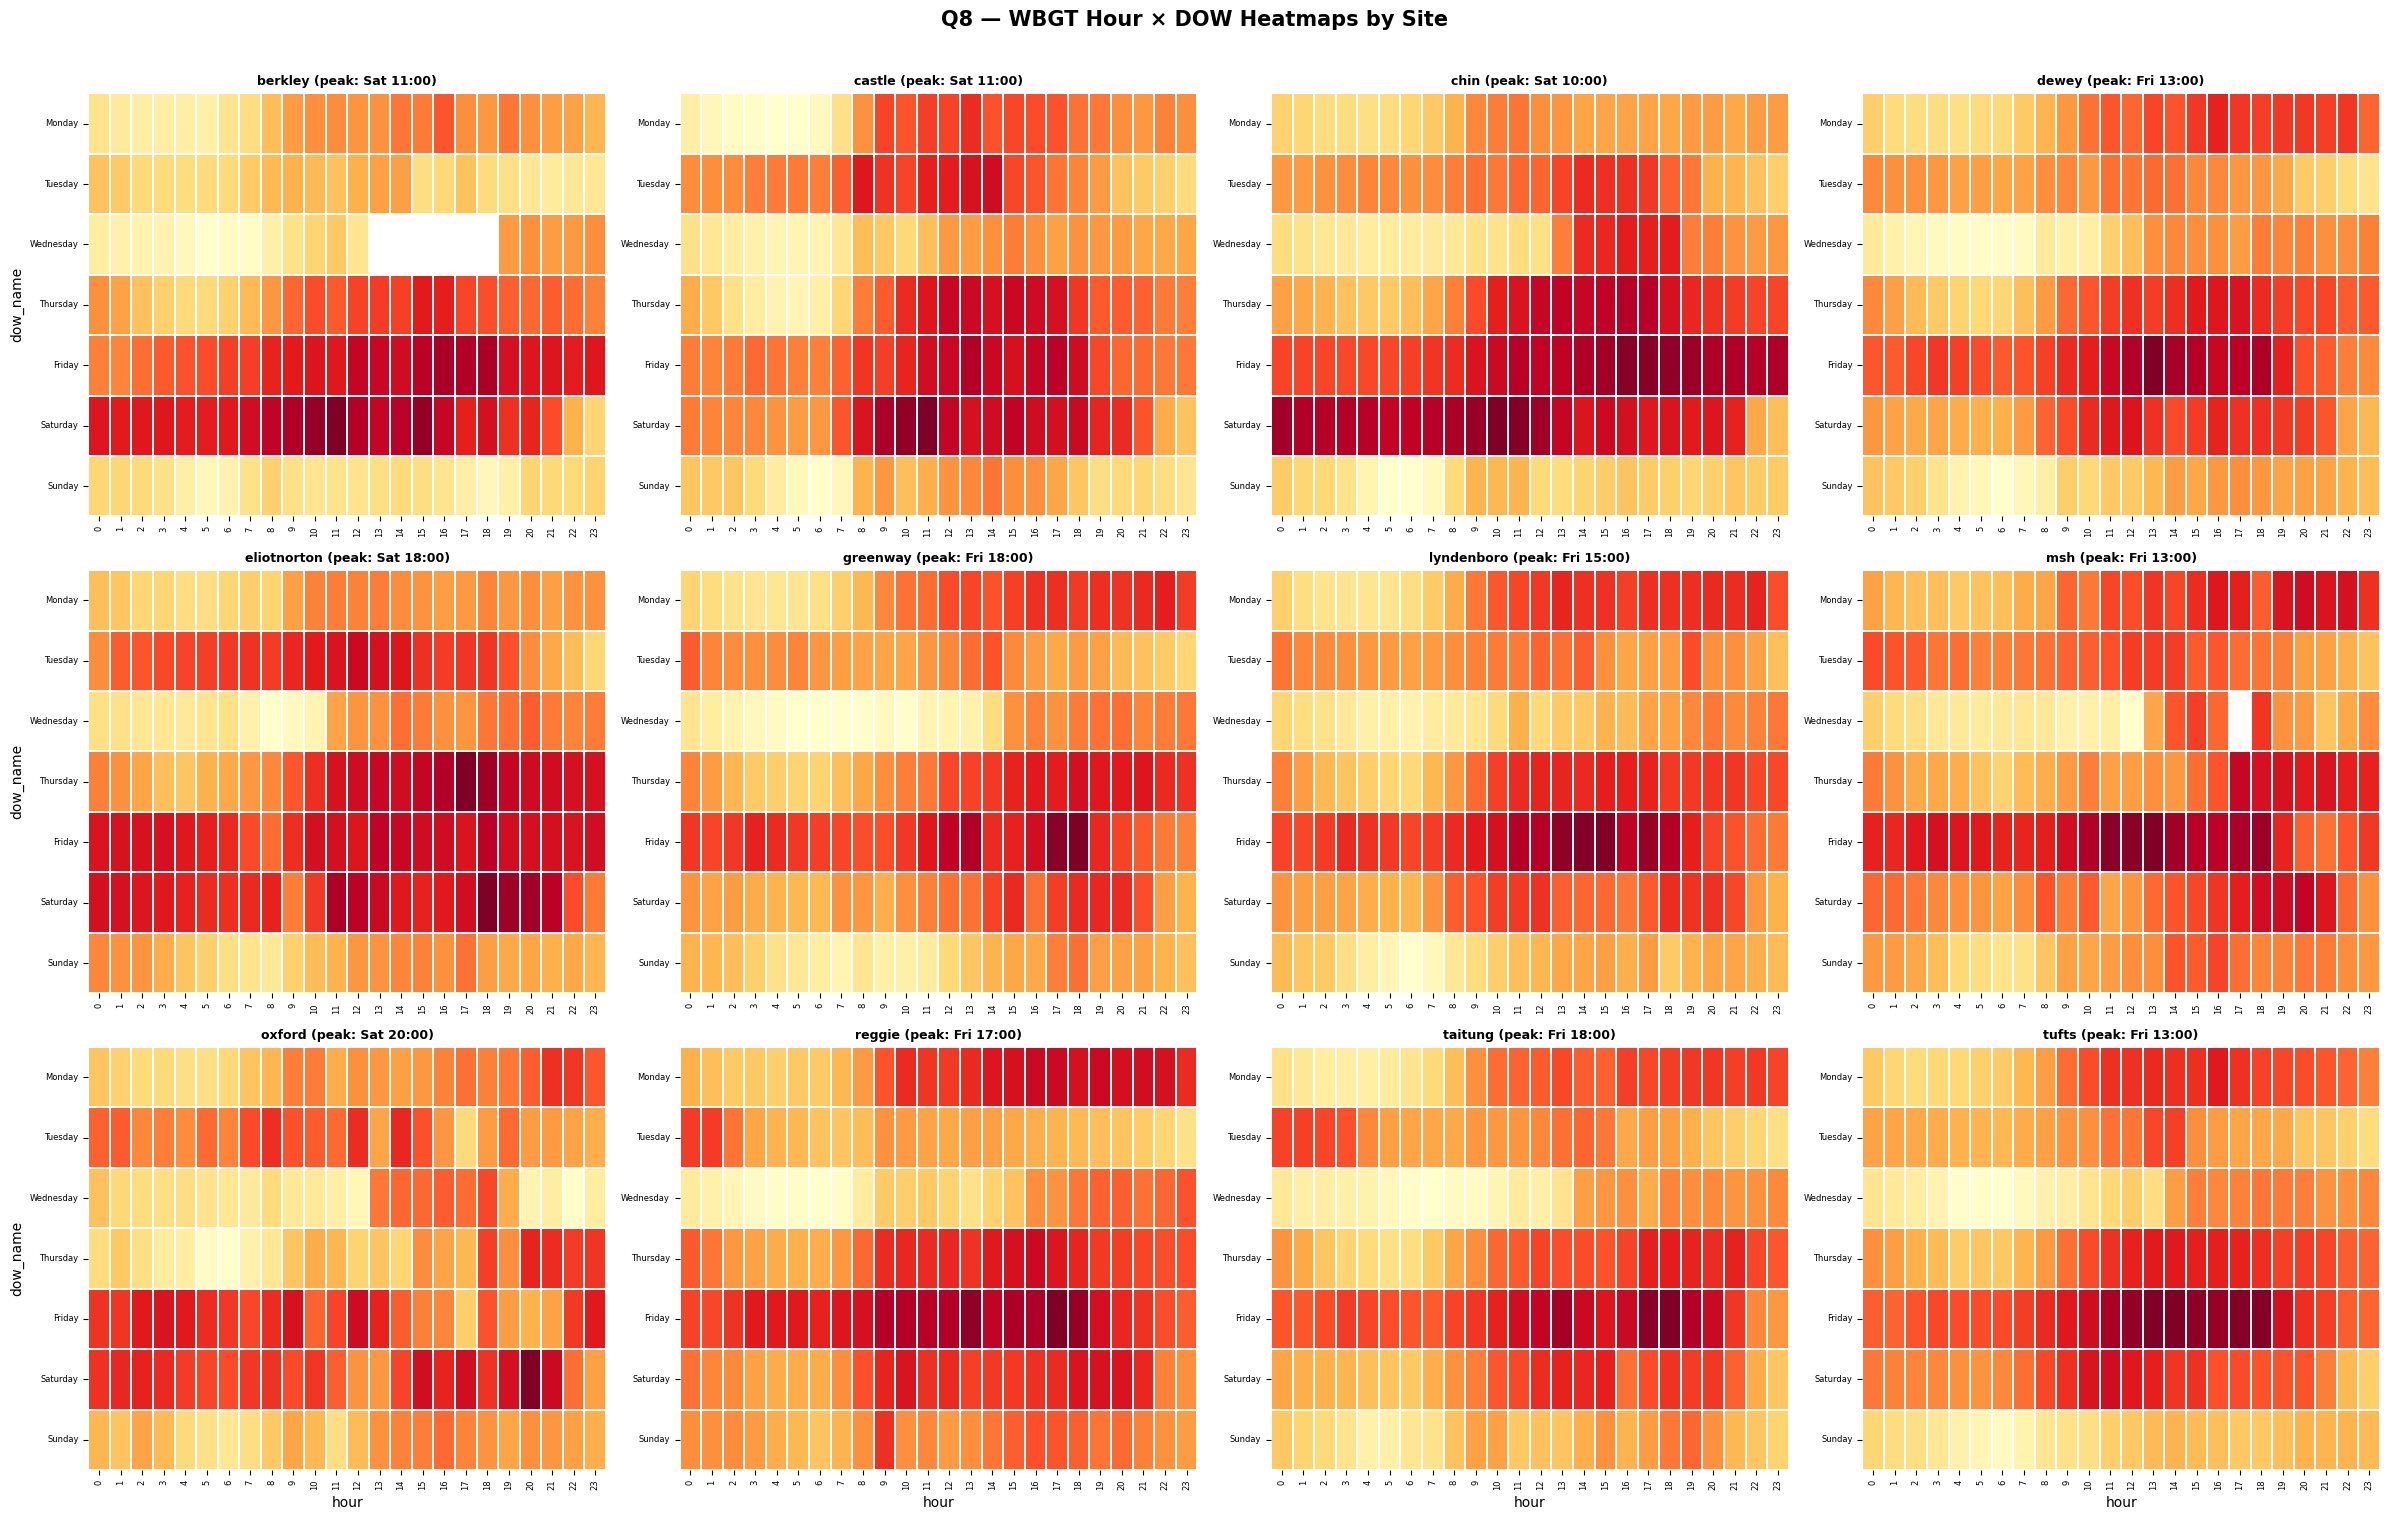

Saved: q8_site_wbgt_heatmaps.png


In [9]:
# ── Per-site WBGT heatmaps ───────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(24, 15))
axes = axes.flat

for idx, s in enumerate(sites):
    ax = axes[idx]
    pivot = df[df['site_id']==s].pivot_table(values=WBGT, index='dow_name', columns='hour', aggfunc='mean')
    pivot = pivot.reindex(DOW_ORDER)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', cbar=False, annot=False, linewidths=0.1)
    peak_idx = np.unravel_index(np.nanargmax(pivot.values), pivot.shape)
    peak_dow = DOW_ORDER[peak_idx[0]][:3]
    peak_h = pivot.columns[peak_idx[1]]
    ax.set_title(f'{s} (peak: {peak_dow} {peak_h}:00)', fontsize=9, fontweight='bold')
    if idx % 4 != 0: ax.set_ylabel('')
    if idx < 8: ax.set_xlabel('')
    ax.tick_params(labelsize=6)

fig.suptitle('Q8 — WBGT Hour × DOW Heatmaps by Site', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'q8_site_wbgt_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: q8_site_wbgt_heatmaps.png')

In [10]:
# ── Site peak-time summary table ─────────────────────────────────
site_peaks = []
for s in sites:
    sd = df[df['site_id']==s]
    h_pm = sd.groupby('hour')[PM].mean()
    h_wb = sd.groupby('hour')[WBGT].mean()
    d_pm = sd.groupby('dow_name')[PM].mean().reindex(DOW_ORDER)
    d_wb = sd.groupby('dow_name')[WBGT].mean().reindex(DOW_ORDER)
    site_peaks.append({
        'site': s,
        'pm25_peak_hr': int(h_pm.idxmax()),
        'pm25_trough_hr': int(h_pm.idxmin()),
        'pm25_amplitude': h_pm.max() - h_pm.min(),
        'pm25_peak_dow': d_pm.idxmax()[:3],
        'pm25_mean': sd[PM].mean(),
        'wbgt_peak_hr': int(h_wb.idxmax()),
        'wbgt_trough_hr': int(h_wb.idxmin()),
        'wbgt_amplitude': h_wb.max() - h_wb.min(),
        'wbgt_peak_dow': d_wb.idxmax()[:3],
        'wbgt_mean': sd[WBGT].mean(),
    })

peaks_df = pd.DataFrame(site_peaks)
print('SITE-LEVEL TEMPORAL PEAK SUMMARY')
print('='*90)
print(f'{"Site":<15} {"PM Peak Hr":>10} {"PM Trough":>10} {"PM Amp":>8} {"PM DOW":>7}'
      f' {"WB Peak Hr":>10} {"WB Trough":>10} {"WB Amp":>8} {"WB DOW":>7}')
print('-'*90)
for _, r in peaks_df.iterrows():
    print(f'{r["site"]:<15} {r["pm25_peak_hr"]:>7}:00 {r["pm25_trough_hr"]:>7}:00 '
          f'{r["pm25_amplitude"]:>7.1f} {r["pm25_peak_dow"]:>7}'
          f' {r["wbgt_peak_hr"]:>7}:00 {r["wbgt_trough_hr"]:>7}:00 '
          f'{r["wbgt_amplitude"]:>7.1f} {r["wbgt_peak_dow"]:>7}')

# Consensus
pm_peak_mode = peaks_df['pm25_peak_hr'].mode()[0]
wb_peak_mode = peaks_df['wbgt_peak_hr'].mode()[0]
print(f'\nConsensus PM2.5 peak hour: {pm_peak_mode}:00 ({(peaks_df["pm25_peak_hr"]==pm_peak_mode).sum()}/{len(sites)} sites)')
print(f'Consensus WBGT  peak hour: {wb_peak_mode}:00 ({(peaks_df["wbgt_peak_hr"]==wb_peak_mode).sum()}/{len(sites)} sites)')

SITE-LEVEL TEMPORAL PEAK SUMMARY
Site            PM Peak Hr  PM Trough   PM Amp  PM DOW WB Peak Hr  WB Trough   WB Amp  WB DOW
------------------------------------------------------------------------------------------
berkley              13:00      18:00     2.5     Fri      15:00       5:00     3.4     Sat
castle               15:00       6:00     3.4     Fri      13:00       5:00     4.1     Sat
chin                 16:00       1:00     3.9     Sat      16:00       5:00     4.3     Sat
dewey                12:00       1:00     2.3     Mon      16:00       6:00     3.6     Fri
eliotnorton          12:00       1:00     2.1     Sat      18:00       8:00     3.3     Fri
greenway             12:00       1:00     2.4     Mon      18:00       6:00     3.4     Fri
lyndenboro           12:00       1:00     1.9     Mon      14:00       6:00     2.9     Fri
msh                  20:00       1:00     1.2     Mon      17:00       6:00     3.1     Fri
oxford               18:00       0:00     2.3 

## Synthesis & Conclusions

In [11]:
# ── Final synthesis ──────────────────────────────────────────────
import os
print('='*70)
print('Q8 — TEMPORAL PATTERNS: FINAL SUMMARY')
print('='*70)

print(f'''
STUDY OVERVIEW
  Period: July 19 – August 23, 2023 ({df['date_only'].nunique()} days)
  Sites: {df['site_id'].nunique()} open-space monitoring locations in Chinatown
  Focus: Temporal (hourly + day-of-week) patterns in PM2.5 and WBGT

DIURNAL PATTERNS (Hour-of-Day)
  PM2.5 peaks at {peak_hr_pm}:00 ({hourly_pm.max():.1f} µg/m³) — nighttime/early morning
  PM2.5 lowest at {trough_hr_pm}:00 ({hourly_pm.min():.1f} µg/m³) — midday
  PM2.5 diurnal amplitude: {pm_amp:.1f} µg/m³
  →  Kruskal-Wallis: H={kw_hr_pm.statistic:.0f}, p={kw_hr_pm.pvalue:.2e} (highly significant)

  WBGT peaks at {peak_hr_wb}:00 ({hourly_wb.max():.1f} °F) — mid-afternoon
  WBGT lowest at {trough_hr_wb}:00 ({hourly_wb.min():.1f} °F) — pre-dawn
  WBGT diurnal amplitude: {wb_amp:.1f} °F
  →  Kruskal-Wallis: H={kw_hr_wb.statistic:.0f}, p={kw_hr_wb.pvalue:.2e} (highly significant)

DAY-OF-WEEK PATTERNS
  PM2.5 peak day: {peak_dow_pm} ({dow_pm.max():.1f} µg/m³)
  WBGT peak day: {peak_dow_wb} ({dow_wb.max():.1f} °F)
  Weekday vs Weekend PM2.5: {wkday_pm:.1f} vs {wkend_pm:.1f} µg/m³
  Weekday vs Weekend WBGT:  {wkday_wb:.1f} vs {wkend_wb:.1f} °F
  →  DOW effect on PM2.5: H={kw_dow_pm.statistic:.0f}, p={kw_dow_pm.pvalue:.2e}
  →  DOW effect on WBGT:  H={kw_dow_wb.statistic:.0f}, p={kw_dow_wb.pvalue:.2e}

KEY INSIGHT: PM2.5 and WBGT have OPPOSITE diurnal cycles
  PM2.5 peaks overnight (boundary layer collapse, traffic residual)
  WBGT peaks mid-afternoon (solar heating)
  This means the worst compound exposure (high PM2.5 + high heat)
  occurs during the transition hours (late afternoon/early evening)

SITE HETEROGENEITY
  PM2.5 peak hour consensus: {pm_peak_mode}:00 ({(peaks_df["pm25_peak_hr"]==pm_peak_mode).sum()}/12 sites)
  WBGT  peak hour consensus: {wb_peak_mode}:00 ({(peaks_df["wbgt_peak_hr"]==wb_peak_mode).sum()}/12 sites)
  PM2.5 amplitude range: {peaks_df["pm25_amplitude"].min():.1f} – {peaks_df["pm25_amplitude"].max():.1f} µg/m³
  WBGT  amplitude range: {peaks_df["wbgt_amplitude"].min():.1f} – {peaks_df["wbgt_amplitude"].max():.1f} °F
''')

q8_figs = sorted([f for f in os.listdir(FIG_DIR) if f.startswith('q8_')])
print(f'FIGURES GENERATED ({len(q8_figs)}):')
for f in q8_figs:
    print(f'  • {f}')

Q8 — TEMPORAL PATTERNS: FINAL SUMMARY

STUDY OVERVIEW
  Period: July 19 – August 23, 2023 (36 days)
  Sites: 12 open-space monitoring locations in Chinatown
  Focus: Temporal (hourly + day-of-week) patterns in PM2.5 and WBGT

DIURNAL PATTERNS (Hour-of-Day)
  PM2.5 peaks at 12:00 (10.6 µg/m³) — nighttime/early morning
  PM2.5 lowest at 1:00 (8.5 µg/m³) — midday
  PM2.5 diurnal amplitude: 2.1 µg/m³
  →  Kruskal-Wallis: H=743, p=3.87e-142 (highly significant)

  WBGT peaks at 17:00 (67.2 °F) — mid-afternoon
  WBGT lowest at 6:00 (64.2 °F) — pre-dawn
  WBGT diurnal amplitude: 3.1 °F
  →  Kruskal-Wallis: H=1896, p=0.00e+00 (highly significant)

DAY-OF-WEEK PATTERNS
  PM2.5 peak day: Monday (10.9 µg/m³)
  WBGT peak day: Friday (68.1 °F)
  Weekday vs Weekend PM2.5: 9.3 vs 10.0 µg/m³
  Weekday vs Weekend WBGT:  66.0 vs 65.6 °F
  →  DOW effect on PM2.5: H=1812, p=0.00e+00
  →  DOW effect on WBGT:  H=3614, p=0.00e+00

KEY INSIGHT: PM2.5 and WBGT have OPPOSITE diurnal cycles
  PM2.5 peaks overnig